<a href="https://colab.research.google.com/github/HarshxJiraya/Plant_disease_detection/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harshvardhan1921","key":"57e9014662588f3cb5ce9251e1988b9c"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:22<00:00, 127MB/s]



In [ ]:
!unzip new-plant-diseases-dataset.zip

In [5]:
!ls -l

total 2829820
-rw-r--r-- 1 root root         72 Jul 20 15:19  kaggle.json
drwxr-xr-x 3 root root       4096 Jul 20 15:21 'new plant diseases dataset(augmented)'
drwxr-xr-x 3 root root       4096 Jul 20 15:19 'New Plant Diseases Dataset(Augmented)'
-rw-r--r-- 1 root root 2897709187 Oct 12  2019  new-plant-diseases-dataset.zip
drwxr-xr-x 1 root root       4096 Jun  4 13:32  sample_data
drwxr-xr-x 3 root root       4096 Jul 20 15:22  test


In [6]:
!du -sh "New Plant Diseases Dataset(Augmented)"
!du -sh "new plant diseases dataset(augmented)"

1.6G	New Plant Diseases Dataset(Augmented)
1.6G	new plant diseases dataset(augmented)


In [7]:
!rm -rf "new plant diseases dataset(augmented)"

In [8]:
!mv "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"/* "/content/New Plant Diseases Dataset(Augmented)/"
!rmdir "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

In [9]:
!mv "/content/test/test"/* "/content/test/"
!rmdir "/content/test/test"

In [10]:
train = "/content/New Plant Diseases Dataset(Augmented)/train"
test = "/content/test"
valid = "/content/New Plant Diseases Dataset(Augmented)/valid"


In [11]:
import os
classes = sorted(os.listdir(train))
print(f"Total number of classes : {len(classes)}")
for cls in classes:
  print(f"Number of images in {cls} : {len(os.listdir(os.path.join(train,cls)))}")

Total number of classes : 38
Number of images in Apple___Apple_scab : 2016
Number of images in Apple___Black_rot : 1987
Number of images in Apple___Cedar_apple_rust : 1760
Number of images in Apple___healthy : 2008
Number of images in Blueberry___healthy : 1816
Number of images in Cherry_(including_sour)___Powdery_mildew : 1683
Number of images in Cherry_(including_sour)___healthy : 1826
Number of images in Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 1642
Number of images in Corn_(maize)___Common_rust_ : 1907
Number of images in Corn_(maize)___Northern_Leaf_Blight : 1908
Number of images in Corn_(maize)___healthy : 1859
Number of images in Grape___Black_rot : 1888
Number of images in Grape___Esca_(Black_Measles) : 1920
Number of images in Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1722
Number of images in Grape___healthy : 1692
Number of images in Orange___Haunglongbing_(Citrus_greening) : 2010
Number of images in Peach___Bacterial_spot : 1838
Number of images in Peach___hea

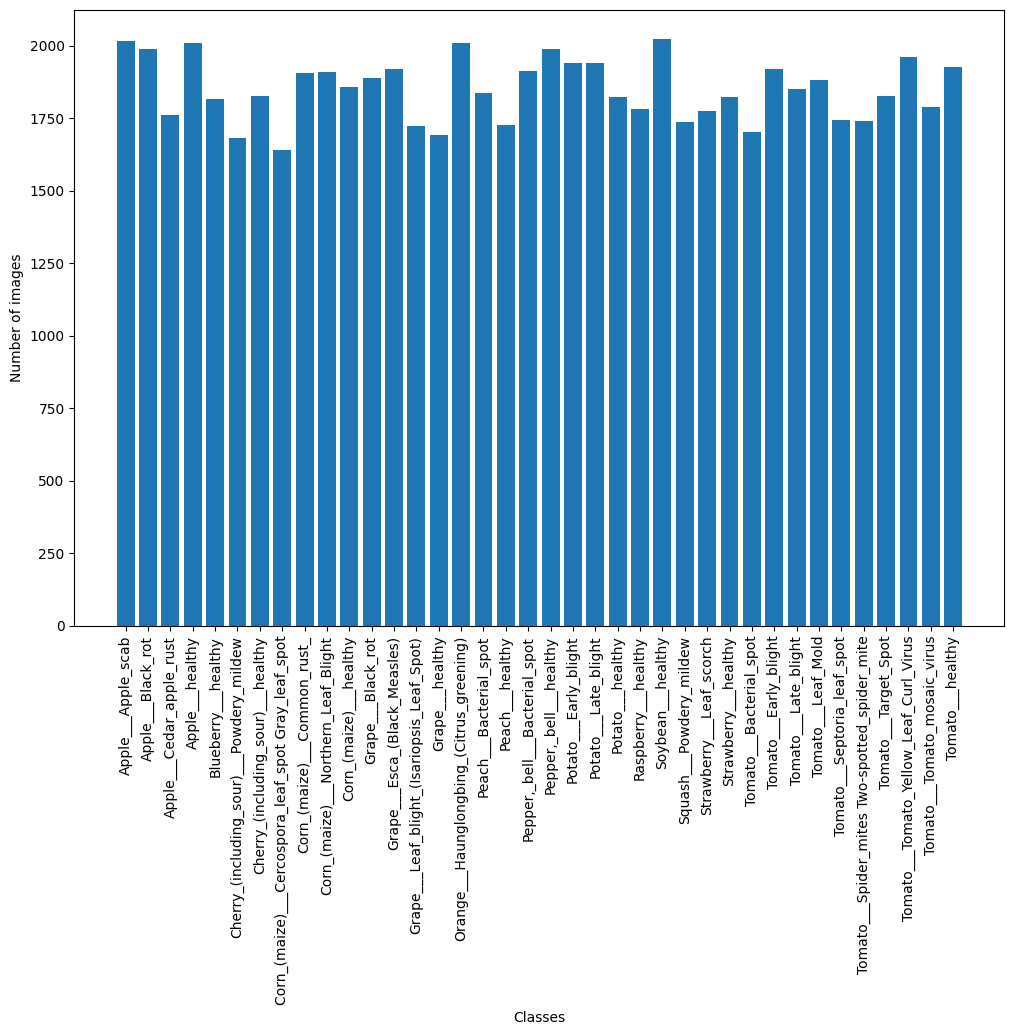

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.bar(classes, [len(os.listdir(os.path.join(train,cls))) for cls in classes])
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Classes")
plt.show()

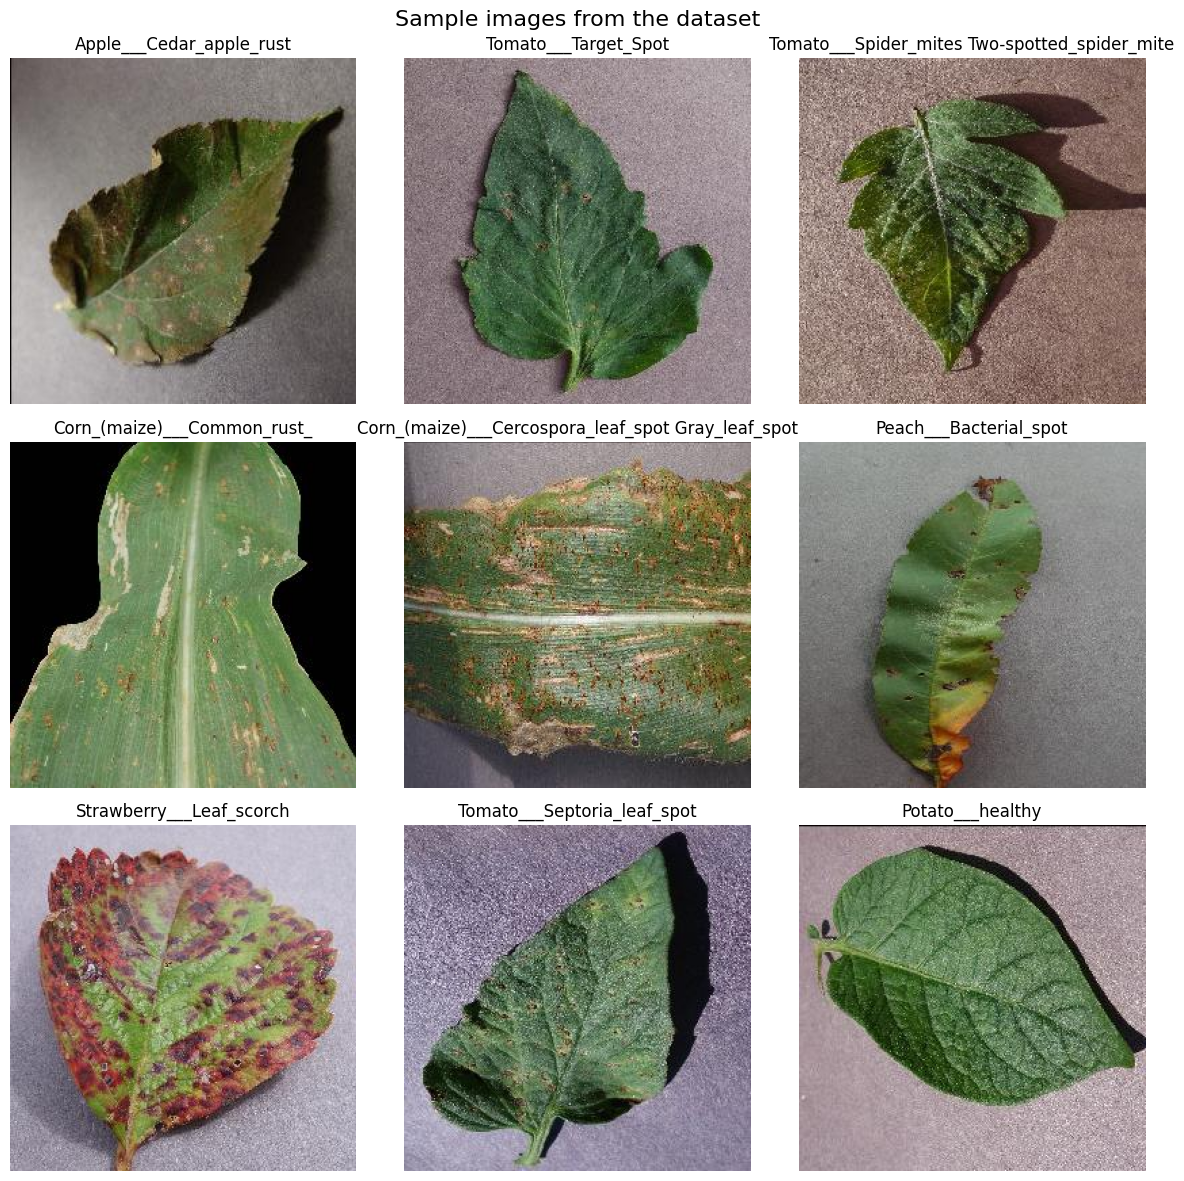

In [13]:
import random
fig,axes = plt.subplots(3,3,figsize=(12,12))
for ax in axes.ravel():
  cls = random.choice(classes)
  img = random.choice(os.listdir(os.path.join(train,cls)))
  ax.imshow(plt.imread(os.path.join(train,cls,img)))
  ax.set_title(cls)
  ax.axis("off")
fig.suptitle("Sample images from the dataset",fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
from PIL import Image
sizes = []
mode = []
for cls in classes:
  folder = os.path.join(train,cls)
  path = os.path.join(folder,os.listdir(folder)[0])
  img = Image.open(path)
  sizes.append(img.size)
  mode.append(img.mode)
if len(set(sizes)) > 1:
  print("Images are of different sizes")
else:
  print("Images are of same size")
if len(set(mode)) > 1:
  print("Images are of different modes")
else:
  print("Images are of same mode")


Images are of same size
Images are of same mode


In [24]:
corrupted = []
for cls in classes:
  folder = os.path.join(train,cls)
  for img in os.listdir(folder):
    path = os.path.join(folder,img)
    try:
      with Image.open(path) as image:
        image.verify()
    except Exception as e:
      corrupted.append((path,str(e)))
if len(corrupted) > 0:
  print(f"Total number of corrupted images : {len(corrupted)}")
else:
  print("No corrupted images found")

No corrupted images found


In [31]:
import pandas as pd
valid_count = []
train_count = []
val_to_train_ratio = []
for cls in classes:
  train_count.append(len(os.listdir(os.path.join(train,cls))))
for cls in classes:
  valid_count.append(len(os.listdir(os.path.join(valid,cls))))
for i,j in zip(train_count,valid_count):
  val_to_train_ratio.append(j/i)
df = pd.DataFrame(
    {
        "Class":classes,
        "Train Count":train_count,
        "Valid Count":valid_count,
        "Valid to Train Ratio":val_to_train_ratio
    }
)
df["Valid to Train Ratio"] = df["Valid to Train Ratio"].round(2)
df.head()


,Class,Train Count,Valid Count,Valid to Train Ratio
0,Apple___Apple_scab,2016,504,0.25
1,Apple___Black_rot,1987,497,0.25
2,Apple___Cedar_apple_rust,1760,440,0.25
3,Apple___healthy,2008,502,0.25
4,Blueberry___healthy,1816,454,0.25


### Data Exploration Summary

1.  **Dataset Overview**: The dataset contains 38 different plant disease classes. Each class has a significant number of images in the training set.
2.  **Image Characteristics**: All images in the dataset are of the same size and mode (RGB), which is beneficial for consistent model training.
3.  **Corrupted Images**: No corrupted images were found in the training dataset, ensuring data quality.

In [32]:
print('--- Train and Validation Data Distribution ---')
display(df)

--- Train and Validation Data Distribution ---


,Class,Train Count,Valid Count,Valid to Train Ratio
0,Apple___Apple_scab,2016,504,0.25
1,Apple___Black_rot,1987,497,0.25
2,Apple___Cedar_apple_rust,1760,440,0.25
3,Apple___healthy,2008,502,0.25
4,Blueberry___healthy,1816,454,0.25
5,Cherry_(including_sour)___Powdery_mildew,1683,421,0.25
6,Cherry_(including_sour)___healthy,1826,456,0.25
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,1642,410,0.25
8,Corn_(maize)___Common_rust_,1907,477,0.25
9,Corn_(maize)___Northern_Leaf_Blight,1908,477,0.25
